Logistic Regression with Iris dataset/personality information


In [123]:
import pandas as pd
import numpy as np 
import seaborn as sb 
import matplotlib.pyplot as plt


In [54]:
# ## Import iris dataset from sklearn
# from sklearn.datasets import load_iris
# iris_dataset = load_iris()
# x = iris_dataset.data
# y = iris_dataset.target

# x

In [124]:
# load personality behaviour dataset
df = pd.read_csv("./datasets/personality_dataset.csv")
df["Stage_fear"] = df["Stage_fear"].map({'Yes':1, 'No':0})
df["Drained_after_socializing"] = df["Drained_after_socializing"].map({'Yes':1, 'No':0})
df["Personality"] = df["Personality"].map({'Extrovert':1, 'Introvert':0})
df.fillna(df.mean(numeric_only=True), inplace=True)

x = df.drop(columns=['Personality']).to_numpy()
y = df['Personality'].to_numpy()
df

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,0.0,4.0,6.0,0.0,13.0,5.0,1
1,9.0,1.0,0.0,0.0,1.0,0.0,3.0,0
2,9.0,1.0,1.0,2.0,1.0,5.0,2.0,0
3,0.0,0.0,6.0,7.0,0.0,14.0,8.0,1
4,3.0,0.0,9.0,4.0,0.0,8.0,5.0,1
...,...,...,...,...,...,...,...,...
2895,3.0,0.0,7.0,6.0,0.0,6.0,6.0,1
2896,3.0,0.0,8.0,3.0,0.0,14.0,9.0,1
2897,4.0,1.0,1.0,1.0,1.0,4.0,0.0,0
2898,11.0,1.0,1.0,3.0,1.0,2.0,0.0,0


In [110]:
#Train test split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)
print(x_train)
print(y_train)


[[ 1.  0.  5. ...  0. 11.  8.]
 [ 5.  1.  1. ...  1.  5.  1.]
 [11.  1.  1. ...  1.  4.  0.]
 ...
 [11.  1.  1. ...  1.  4.  2.]
 [10.  1.  3. ...  1.  5.  0.]
 [ 4.  1.  2. ...  1.  3.  1.]]
[1 0 0 ... 0 0 0]


In [122]:
#standardize the data
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()

x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)
x_train, y_train

(array([[-1.02531533, -1.02605564,  0.38113899, ..., -1.01002396,
          1.13080286,  1.55562091],
        [ 0.13057102,  1.00023172, -1.01754524, ...,  1.00542723,
         -0.28681065, -0.877092  ],
        [ 1.86440053,  1.00023172, -1.01754524, ...,  1.00542723,
         -0.52307957, -1.22462241],
        ...,
        [ 1.86440053,  1.00023172, -1.01754524, ...,  1.00542723,
         -0.52307957, -0.52956158],
        [ 1.57542895,  1.00023172, -0.31820313, ...,  1.00542723,
         -0.28681065, -1.22462241],
        [-0.15840057,  1.00023172, -0.66787418, ...,  1.00542723,
         -0.75934848, -0.877092  ]], shape=(2030, 7)),
 array([1, 0, 0, ..., 0, 0, 0], shape=(2030,)))

AttributeError: module 'seaborn' has no attribute 'show'

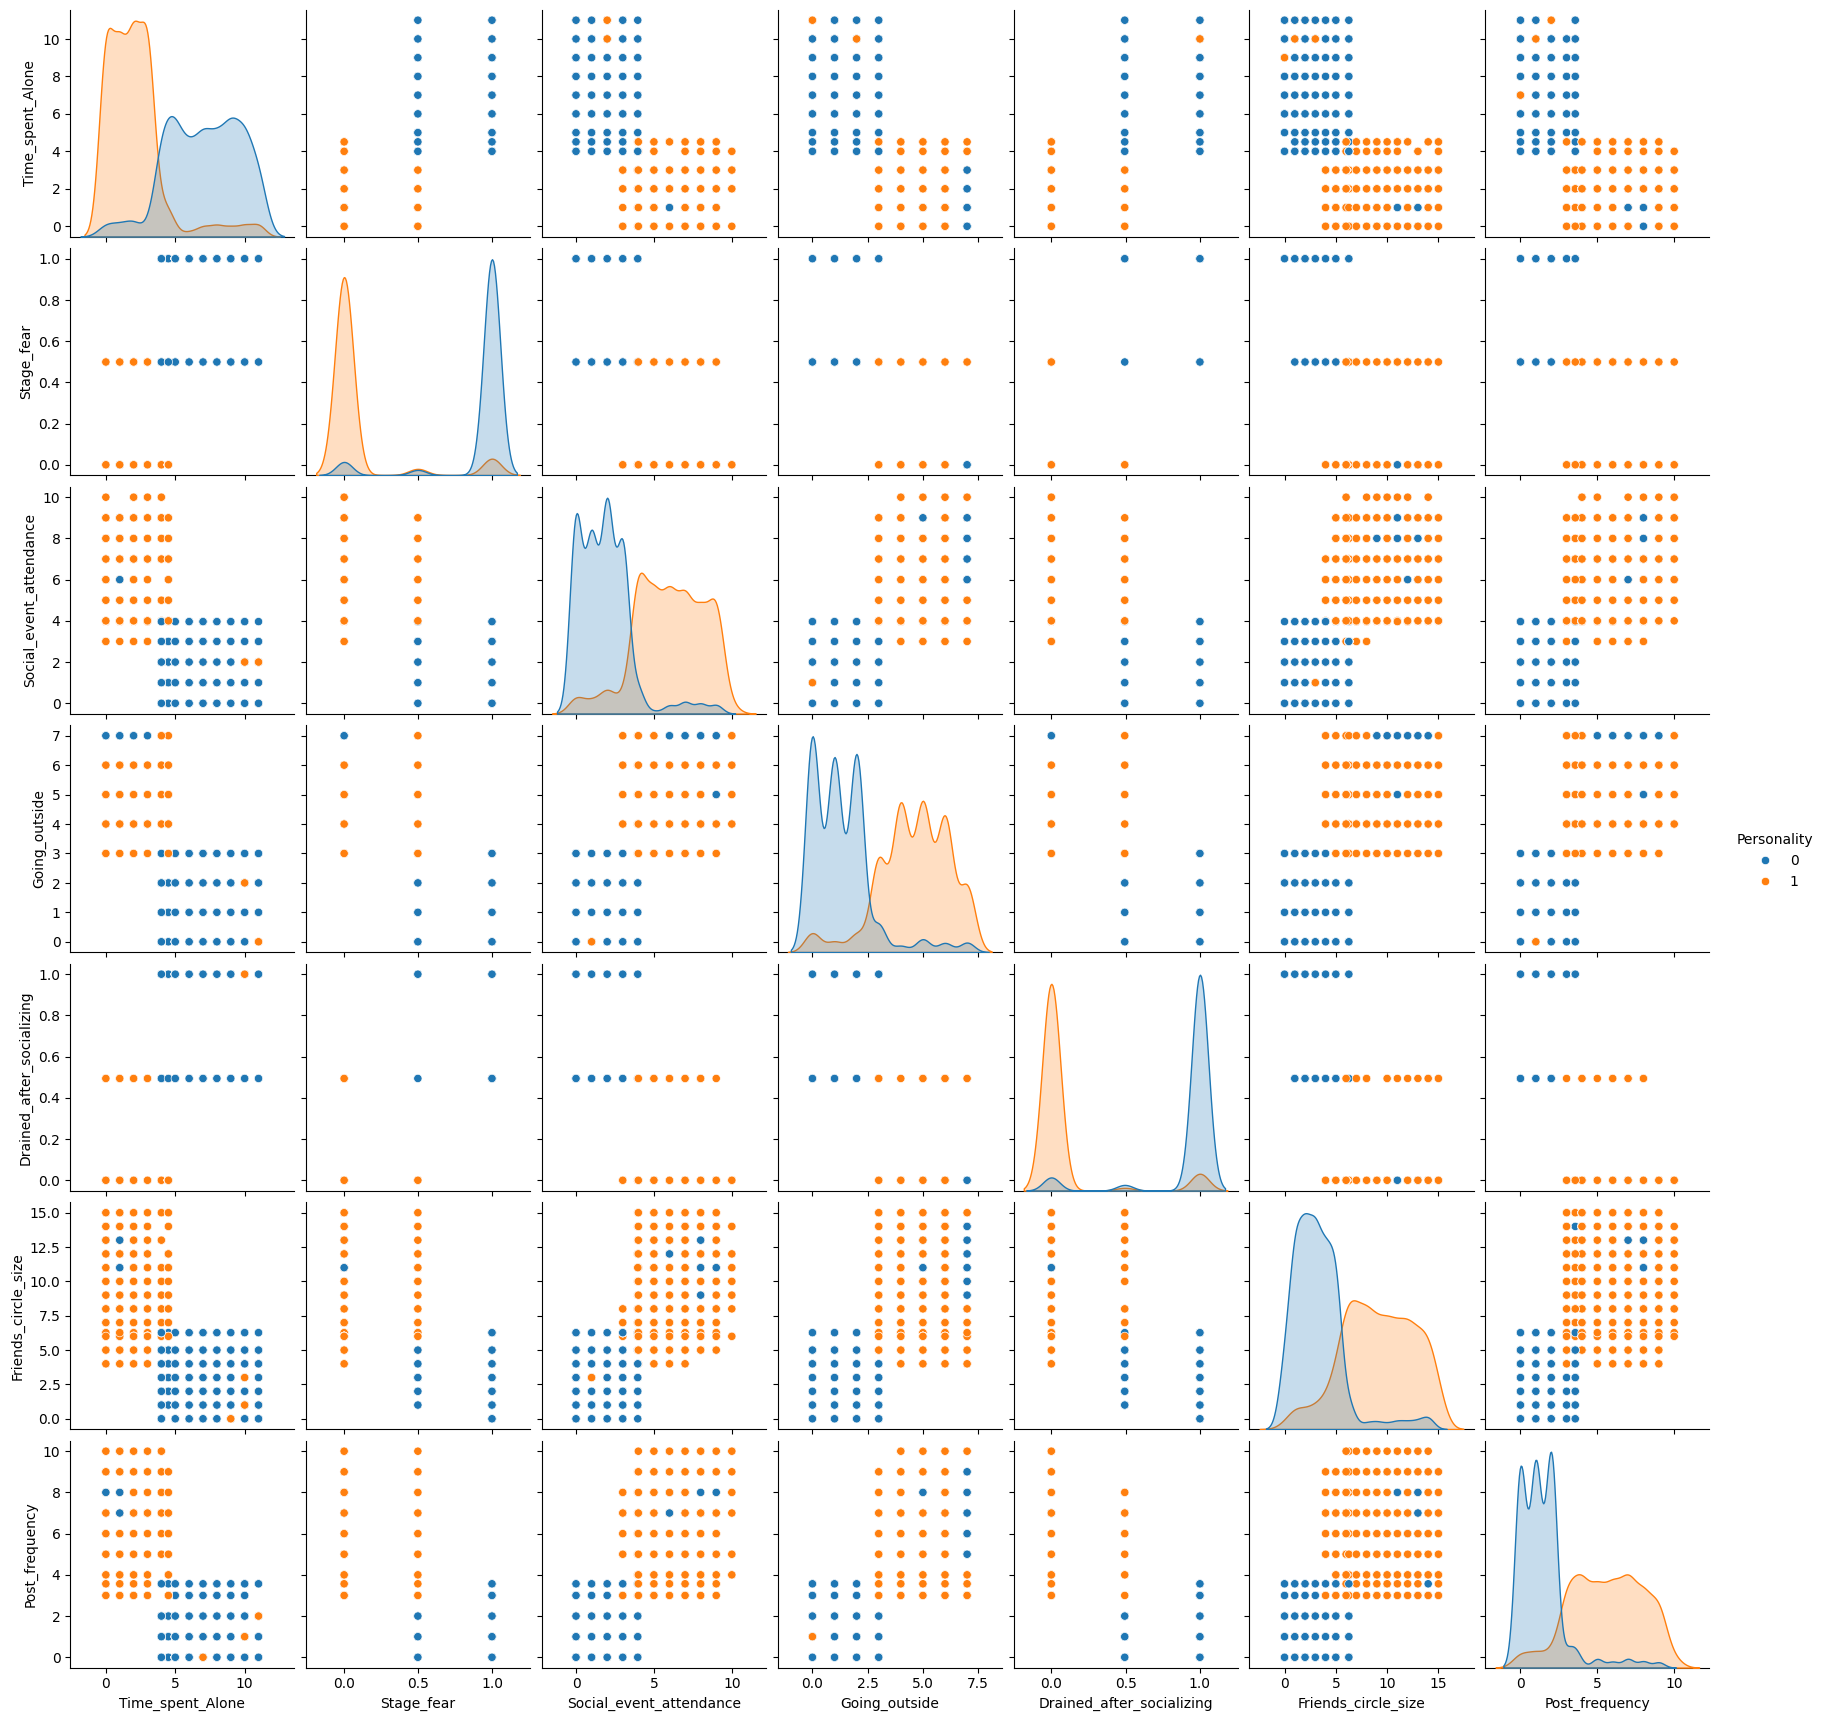

In [128]:
# Plotting the training data
sb.pairplot(df, hue='Personality')
sb.show()



In [112]:
# create linear model for logistic regression 
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression()


In [113]:
#select appropriate model for classifier
from sklearn.model_selection import GridSearchCV
parameter={'penalty':['l1','l2'],'C':[1,2,3,4,5,6,10,20,30,40,50],'max_iter':[100,200,300]}

In [114]:
#create classifier regressor for clasification 
classifier_regressor=GridSearchCV(classifier,param_grid=parameter,scoring='accuracy',cv=5)

In [115]:
#Fit model with data
classifier_regressor.fit(x_train,y_train)

c:\Users\sancram\workspace\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
165 fits failed out of a total of 330.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
165 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\sancram\workspace\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\sancram\workspace\.venv\Lib\site-packages\sklearn\base.py", line 1363, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\sancram\workspace\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py

,estimator,LogisticRegression()
,param_grid,"{'C': [1, 2, ...], 'max_iter': [100, 200, ...], 'penalty': ['l1', 'l2']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [116]:
print(classifier_regressor.best_params_)
print(classifier_regressor.best_score_)

{'C': 1, 'max_iter': 100, 'penalty': 'l2'}
0.9344827586206895


In [117]:
##prediction
y_pred=classifier_regressor.predict(x_test)

In [118]:
## accuracy score
from sklearn.metrics import accuracy_score,classification_report
score=accuracy_score(y_pred,y_test)
print(score)
print(classification_report(y_pred,y_test))

0.9252873563218391
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       414
           1       0.92      0.94      0.93       456

    accuracy                           0.93       870
   macro avg       0.93      0.92      0.93       870
weighted avg       0.93      0.93      0.93       870



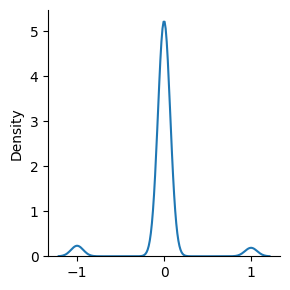

In [121]:
sb.displot(y_pred-y_test, kind='kde', height=3, )

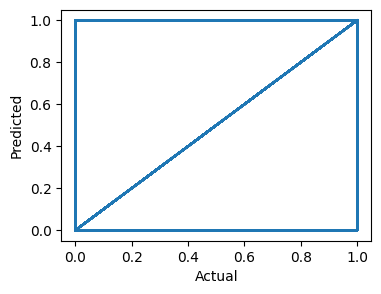

In [120]:
# adding visualization to the code
import matplotlib.pyplot as plt
plt.figure(figsize=[4, 3])
plt.plot(y_pred, y_test)
plt.xlabel("Actual")
plt.ylabel("Predicted")


plt.show()

In [138]:
test = [[ 0.57542895,  1.00023172, -1.31820313,  0.10927689,  0.00542723,
       -4.28681065, -1.18203117]]
test_pred=classifier_regressor.predict(test)
test_pred

array([1])